# **Вторичный анализ данных**



## <b>Сбор и очистка данных</b>

Парсер находится в файле parser.py и собирает данные с сайта mirkvartir.ru. Соберем 10000 предложений со случайных страниц сайта. Сохраняем в файл main_data10000.csv. Собранные объекты имеют слудующие параметры:

id - идентификатор;<br>
url - ссылка на предложение;<br>
title - заголовок;<br>
price - стоимость аренды за месяц;<br>
laltitude - широта в координатах;<br>
longitude - долгота в координатах;<br>
metro_name - название ближайшей станции метро;<br>
metro_distanse - расстояние до метро в минутах;<br>
distanceType - тип транспорта, на котором можно добраться до метро за указанное  количество минут;<br>
update_time - время последнего обновления предложения.
<br><br>
Опираемся на признаки, полученные из первичного анализа: площадь, количество комнат, расстояние до центра.

In [51]:
import os
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive/


In [111]:
import pandas as pd
import numpy as np
offers = pd.read_csv('main_data10000.csv')
print(len(offers))
offers.head(5)

10000


,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32


Парсим заголовок и разделяем данные на столбцы. (rooms, area, floor, max_floor)

In [112]:
def filter_parse_strings(offers_file: str, output_file: str):
    offers = pd.read_csv(offers_file)
    rooms = []
    area = []
    floor = []
    max_floor = []
    for i in range(len(offers)):
        offer = offers.iloc[i]
        room, ar, fl = offer.title.split(', ')
        if room == 'Студия':
            room = 0
        else:
            room = int(room[0])

        ar = float(ar.split()[0])
        if '/' not in fl:
          mx_fl = np.nan
        else:
          mx_fl = int(fl.split()[0].split('/')[1])
        fl = int(fl.split()[0].split('/')[0])
        rooms.append(room)
        area.append(ar)
        floor.append(fl)
        max_floor.append(mx_fl)

    offers['rooms'] = rooms
    offers['area'] = area
    offers['floor'] = floor
    offers['max_floor'] = max_floor
    offers = offers.dropna(subset=['max_floor'])
    offers['max_floor'] = offers['max_floor'].astype(int)
    offers['price_per_sqm'] = offers['price'] / offers['area']
    offers.to_csv(output_file, index=False)

    return None


filter_parse_strings('main_data10000.csv', 'data_filter2.csv')
offers = pd.read_csv('data_filter2.csv')
print(len(offers))
offers.head(5)

9993


,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time,rooms,area,floor,max_floor,price_per_sqm
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57,3,80.000000,5,5,1312.500000
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29,4,170.000000,5,5,1764.705882
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03,2,51.000000,4,9,980.392157
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00,3,74.700000,5,6,2141.900937
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32,3,120.000000,2,4,2750.000000


Избавимся от ненужных столбцов и обезличим данные.

In [113]:
from geopy.distance import geodesic


def add_centre_distance(offers_file: str, output_file: str) -> None:
    """
    функция добавляет к каждому объявлению расстояние от
    квартиры до метро в координатах
    :param stations_file: json файл с информацией о станциях метро
    :param offers_file: csv файл с объявлениями
    :return: None
    """
    offers = pd.read_csv(offers_file)
    centre_distance = []
    for i in range(len(offers)):
        offer = offers.iloc[i]
        flat_cords = (float(offer.latitude), float(offer.longitude))
        centre_coords = (59.93, 30.32)
        centre_distance.append(geodesic((offer.latitude, offer.longitude), centre_coords).meters)

    offers['centre_distance'] = centre_distance
    offers.to_csv(output_file, index=False)
    return None


add_centre_distance("data_filter2.csv", 'data_filter4.csv')
offers = pd.read_csv('data_filter4.csv')
offers.head(5)

,id,url,title,price,latitude,longitude,metro_name,metro_distance,distanceType,update_time,rooms,area,floor,max_floor,price_per_sqm,centre_distance
0,348929935,https://arenda.mirkvartir.ru/348929935/,"3-комн. квартира, 80 м2, 5/5 этаж",105000,59.987354,30.294416,Пионерская,NaN,0.000000,2025-08-26T20:20:57,3,80.000000,5,5,1312.500000,6547.817295
1,349962437,https://arenda.mirkvartir.ru/349962437/,"4-комн. квартира, 170 м2, 5/5 этаж",300000,59.934032,30.340858,Лиговский проспект,NaN,0.000000,2025-09-12T19:04:29,4,170.000000,5,5,1764.705882,1249.783954
2,349277934,https://arenda.mirkvartir.ru/349277934/,"2-комн. квартира, 51 м2, 4/9 этаж",50000,59.916557,30.479397,Улица Дыбенко,NaN,0.000000,2025-08-21T01:41:03,2,51.000000,4,9,980.392157,9039.866588
3,350633681,https://arenda.mirkvartir.ru/350633681/,"3-комн. квартира, 74.7 м2, 5/6 этаж",160000,59.968624,30.312634,Горьковская,NaN,0.000000,2025-09-26T07:10:00,3,74.700000,5,6,2141.900937,4322.799892
4,349962462,https://arenda.mirkvartir.ru/349962462/,"3-комн. квартира, 120 м2, 2/4 этаж",330000,59.936436,30.326288,Сенная площадь,NaN,0.000000,2025-09-12T13:40:32,3,120.000000,2,4,2750.000000,798.596324


In [114]:
offers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               9993 non-null   int64  
 1   url              9993 non-null   object 
 2   title            9993 non-null   object 
 3   price            9993 non-null   int64  
 4   latitude         9993 non-null   float64
 5   longitude        9993 non-null   float64
 6   metro_name       7443 non-null   object 
 7   metro_distance   1016 non-null   float64
 8   distanceType     7443 non-null   float64
 9   update_time      9993 non-null   object 
 10  rooms            9993 non-null   int64  
 11  area             9993 non-null   float64
 12  floor            9993 non-null   int64  
 13  max_floor        9993 non-null   int64  
 14  price_per_sqm    9993 non-null   float64
 15  centre_distance  9993 non-null   float64
dtypes: float64(7), int64(5), object(4)
memory usage: 1.2+ MB


In [115]:
def filter_only_for_training(input_file, output_file):
    offers = pd.read_csv(input_file)

    offers.drop('title', axis=1, inplace=True)
    offers.drop('url', axis=1, inplace=True)
    offers.drop('metro_distance', axis=1, inplace=True)
    offers.drop('distanceType', axis=1, inplace=True)
    offers.drop('update_time', axis=1, inplace=True)
    offers.drop('metro_name', axis=1, inplace=True)

    offers.to_csv(output_file, index=False)
    return None


filter_only_for_training('data_filter4.csv', 'data_filter5.csv')
offers = pd.read_csv('data_filter5.csv')
offers.head(5)


,id,price,latitude,longitude,rooms,area,floor,max_floor,price_per_sqm,centre_distance
0,348929935,105000,59.987354,30.294416,3,80.000000,5,5,1312.500000,6547.817295
1,349962437,300000,59.934032,30.340858,4,170.000000,5,5,1764.705882,1249.783954
2,349277934,50000,59.916557,30.479397,2,51.000000,4,9,980.392157,9039.866588
3,350633681,160000,59.968624,30.312634,3,74.700000,5,6,2141.900937,4322.799892
4,349962462,330000,59.936436,30.326288,3,120.000000,2,4,2750.000000,798.596324


Сбор данных происходил со случайных страниц, поэтому не исключены дубликаты строк. Найдем и очистим их.

In [116]:
print(offers.duplicated().sum())
offers = offers.drop_duplicates()
print(offers.duplicated().sum())
print(len(offers))
offers.to_csv('data_filter6.csv', index=False)

3620
0
6373


## <b>Анализ данных</b>

Посмотрим распределение данных и проанализируем выбросы, которые плохо повлияют на модель с новыми данными.

In [117]:
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
offers.describe(percentiles=[.01, .25, .5, .75, .99]).T



,count,mean,std,min,1%,25%,50%,75%,99%,max
id,6373.000000,351310503.926722,17206152.939385,209090582.000000,259374559.280000,351174111.000000,357542438.000000,358560083.000000,359169379.360000,359202152.000000
price,6373.000000,55467.431665,55065.865964,5000.000000,20000.000000,33000.000000,40000.000000,60000.000000,280000.000000,1602300.000000
latitude,6373.000000,59.933412,0.087371,59.654845,59.730502,59.861647,59.936548,60.006273,60.083866,60.207916
longitude,6373.000000,30.322123,0.115123,29.662540,29.954784,30.250713,30.329126,30.403122,30.554630,30.630125
rooms,6373.000000,1.248235,1.041157,0.000000,0.000000,0.000000,1.000000,2.000000,4.000000,9.000000
area,6373.000000,46.455045,31.289567,10.000000,15.000000,30.000000,39.000000,54.600000,163.000000,1000.000000
floor,6373.000000,7.001412,5.161409,1.000000,1.000000,3.000000,5.000000,10.000000,23.000000,28.000000
max_floor,6373.000000,12.729484,6.686172,1.000000,3.000000,7.000000,12.000000,17.000000,27.000000,35.000000
price_per_sqm,6373.000000,1207.160138,484.892979,67.979372,570.095238,897.435897,1083.333333,1395.348837,2941.176471,6842.105263
centre_distance,6373.000000,10190.119552,5700.498900,37.269770,796.085462,6344.566493,9760.195933,13331.628774,27174.889470,47126.491665


**1. Ценовые показатели (price):**

Средняя цена 55,467 руб, но есть экстремальные выбросы (макс 1,6 млн руб). 99% цен ниже 280,000 руб, что разумно для аренды. Медиана 40,000 руб показывает правостороннюю асимметрию.

**2. Географические координаты (latitude, longitude):**

Разброс координат соответствует границам СПб. Среднее положение (59.93, 30.32) - центр города. Стандартные отклонения малы (0.087 и 0.115), что говорит о хорошей географической кластеризации данных.

**3. Характеристики жилья:**

rooms: Медиана 1 комната, 75% квартир имеют ≤2 комнаты.

area: Средняя площадь 46.46 м², но в 99% входят и крупные объекты (163 м²).

Этажность: медианные значения floor=5 и max_floor=12 типичны для СПб.

**4. Расстояние до центра:**

centre_distance: Среднее расстояние до центра 10,190 м, медианное расстояние почти такое же (9,760 м). Есть аномалии - 47 км.

<br>

Экстремальные выбросы в price (1.6 млн).

Широкий разброс в centre_distance (от 37 м до 47 км).

Расхождение между средним и медианным price (55,467 vs 40,000) указывает на ненормальное распределение.

Рынок аренды в основном представлен 1-2 комнатными квартирами (~46,5 м²).

Геоданные показывают хорошее покрытие по всему городу без явных "дыр".



Отфильтруем выбросы:

In [118]:
price_lower = offers['price'].quantile(0.01)
price_upper = offers['price'].quantile(0.99)
centre_max = offers['centre_distance'].quantile(0.96)
max_area = offers['area'].quantile(0.995)

offers_filtered = offers[
    (offers['price'] >= price_lower) &
    (offers['price'] <= price_upper) &
    (offers['centre_distance'] <= centre_max) &
    (offers['area'] <= max_area)
].copy()

print(f"Удалено {len(offers) - len(offers_filtered)} строк (выбросы по цене, площади и расстоянию до центра)")
offers_filtered.to_csv('final_data.csv', index=False)

Удалено 357 строк (выбросы по цене, площади и расстоянию до центра)


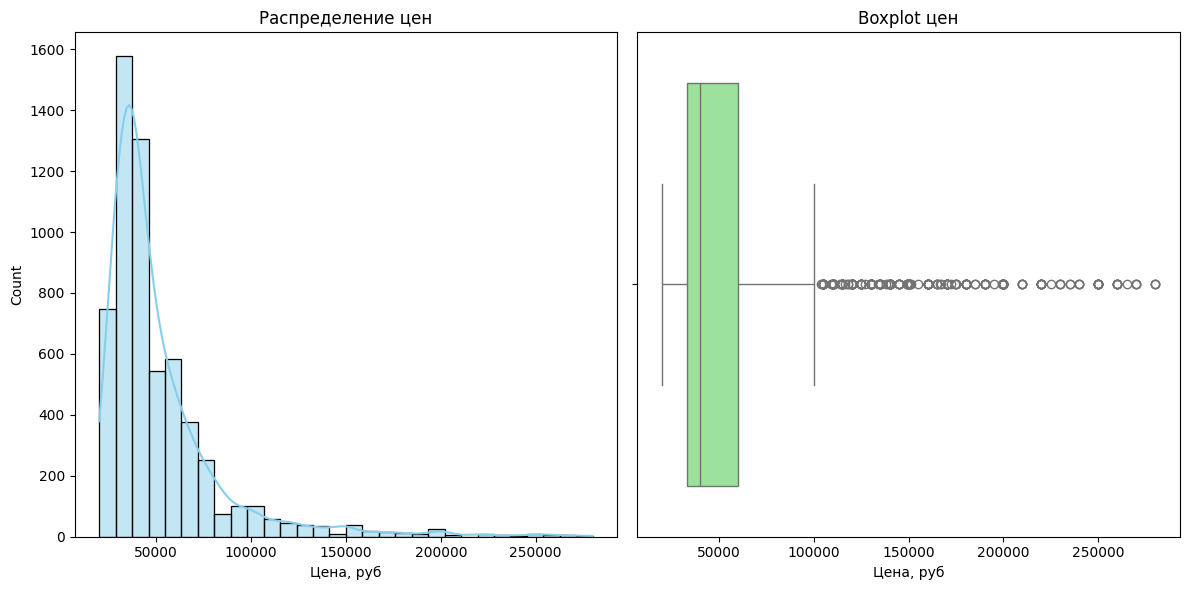

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(offers_filtered['price'], bins=30, kde=True, color='skyblue')
plt.title("Распределение цен")
plt.xlabel("Цена, руб")

plt.subplot(1, 2, 2)
sns.boxplot(x=offers_filtered['price'], color='lightgreen')
plt.title("Boxplot цен")
plt.xlabel("Цена, руб")
plt.tight_layout()
plt.show()

Распределение цен немного изменилось, но это слабо волияет на даные в целом.

/tmp/ipykernel_10419/34914051.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rooms', y='price', data=room_price, ax=axes[0, 1], palette='Blues_d')


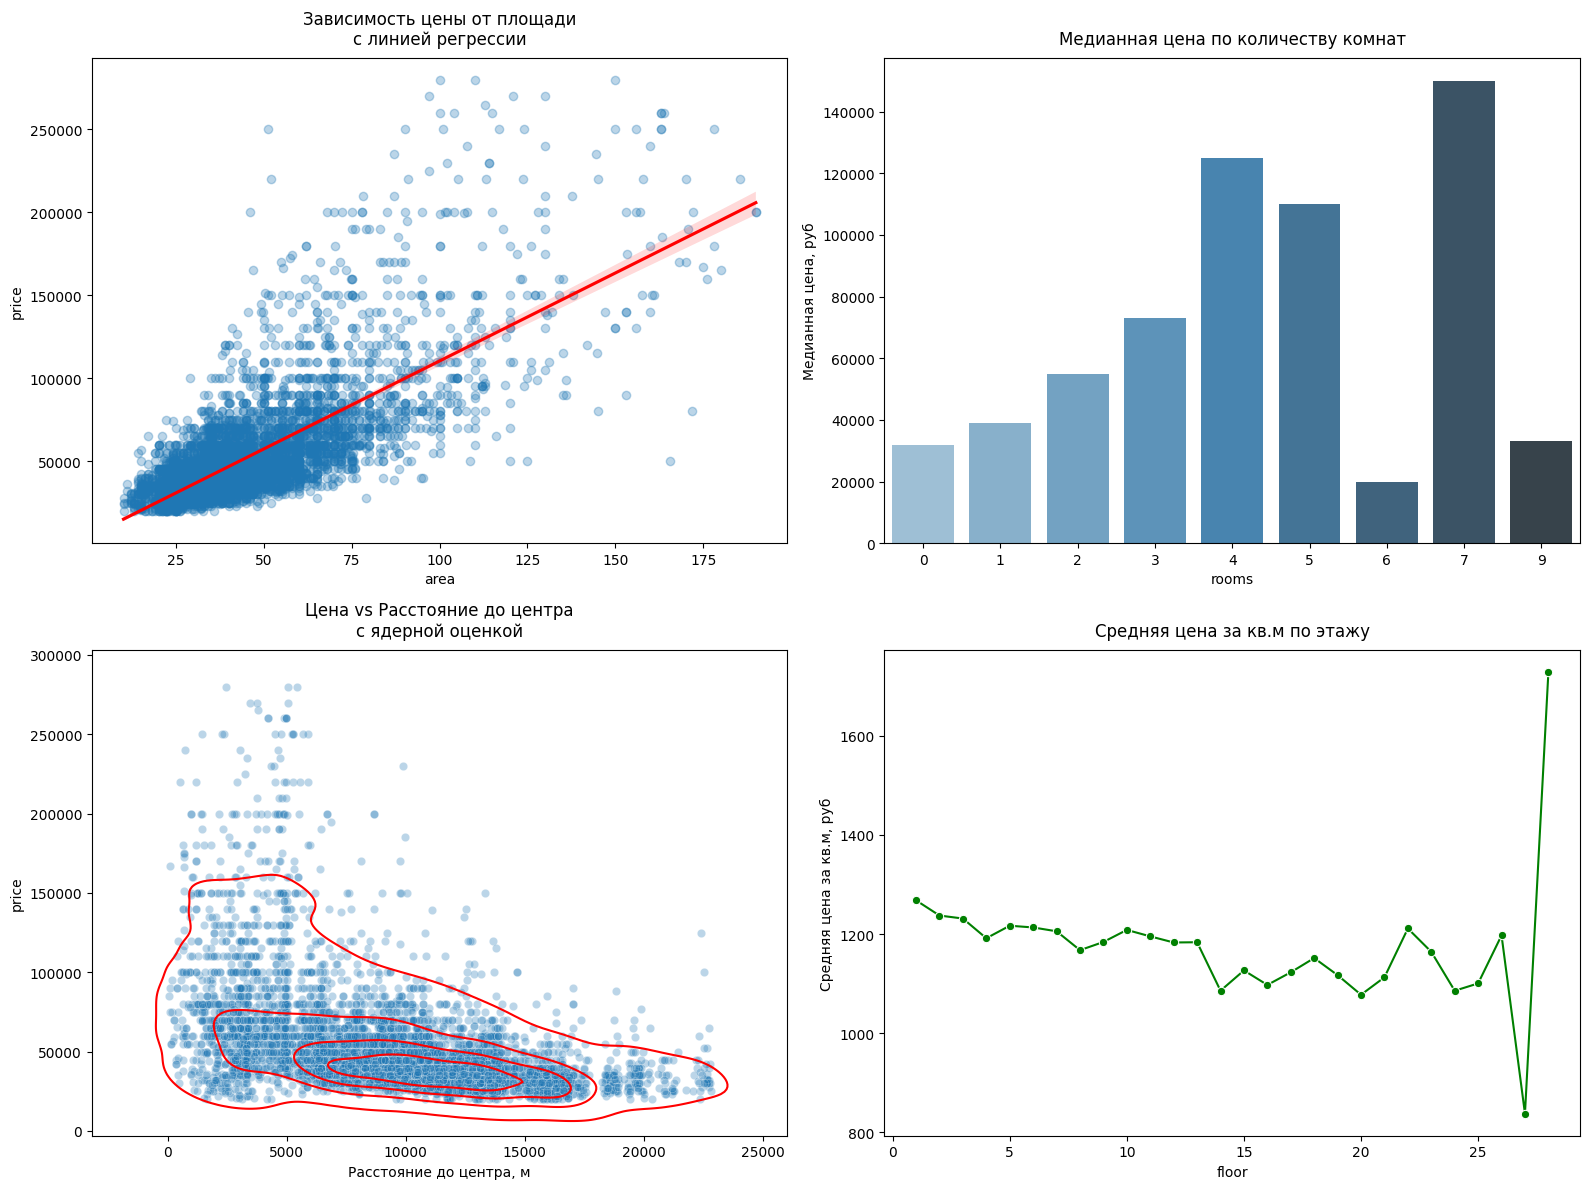

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(x='area', y='price', data=offers_filtered,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'},
            ax=axes[0, 0])
axes[0, 0].set_title("Зависимость цены от площади\nс линией регрессии", pad=10)

room_price = offers_filtered.groupby('rooms')['price'].median().reset_index()
sns.barplot(x='rooms', y='price', data=room_price, ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title("Медианная цена по количеству комнат", pad=10)
axes[0, 1].set_ylabel("Медианная цена, руб")

sns.scatterplot(x='centre_distance', y='price', data=offers_filtered,
                alpha=0.3, ax=axes[1, 0])
sns.kdeplot(x='centre_distance', y='price', data=offers_filtered,
            levels=5, color='red', ax=axes[1, 0])
axes[1, 0].set_title("Цена vs Расстояние до центра\nс ядерной оценкой", pad=10)
axes[1, 0].set_xlabel("Расстояние до центра, м")
floor_price = offers_filtered.groupby('floor')['price_per_sqm'].mean().reset_index()
sns.lineplot(x='floor', y='price_per_sqm', data=floor_price,
             marker='o', ax=axes[1, 1], color='green')
axes[1, 1].set_title("Средняя цена за кв.м по этажу", pad=10)
axes[1, 1].set_ylabel("Средняя цена за кв.м, руб")
plt.tight_layout()
plt.show()

Наблюдается положительная корреляция между площадью и ценой: с увеличением площади цена также увеличивается. Линия регрессии показывает общую тенденцию роста цен с увеличением площади, хотя есть разброс данных, особенно на больших площадях.

Медианная цена увеличивается с ростом количества комнат. Особенно заметен рост цен на квартиры с 4, 5 и 7 комнатами.

Наибольшая концентрация более дорогих объектов находится от 5000 м до 15000 м до центра города. С увеличением расстояния от центра цены, как правило, снижаются.

Видно, что средняя цена за квадратный метр варьируется в зависимости от этажа, но зависимости не наблюдается.

Можно заметить концентрацию более дорогих квартир в центре, имеет смыст добавить признак расстояния до центра города, найденного из статистических данных.

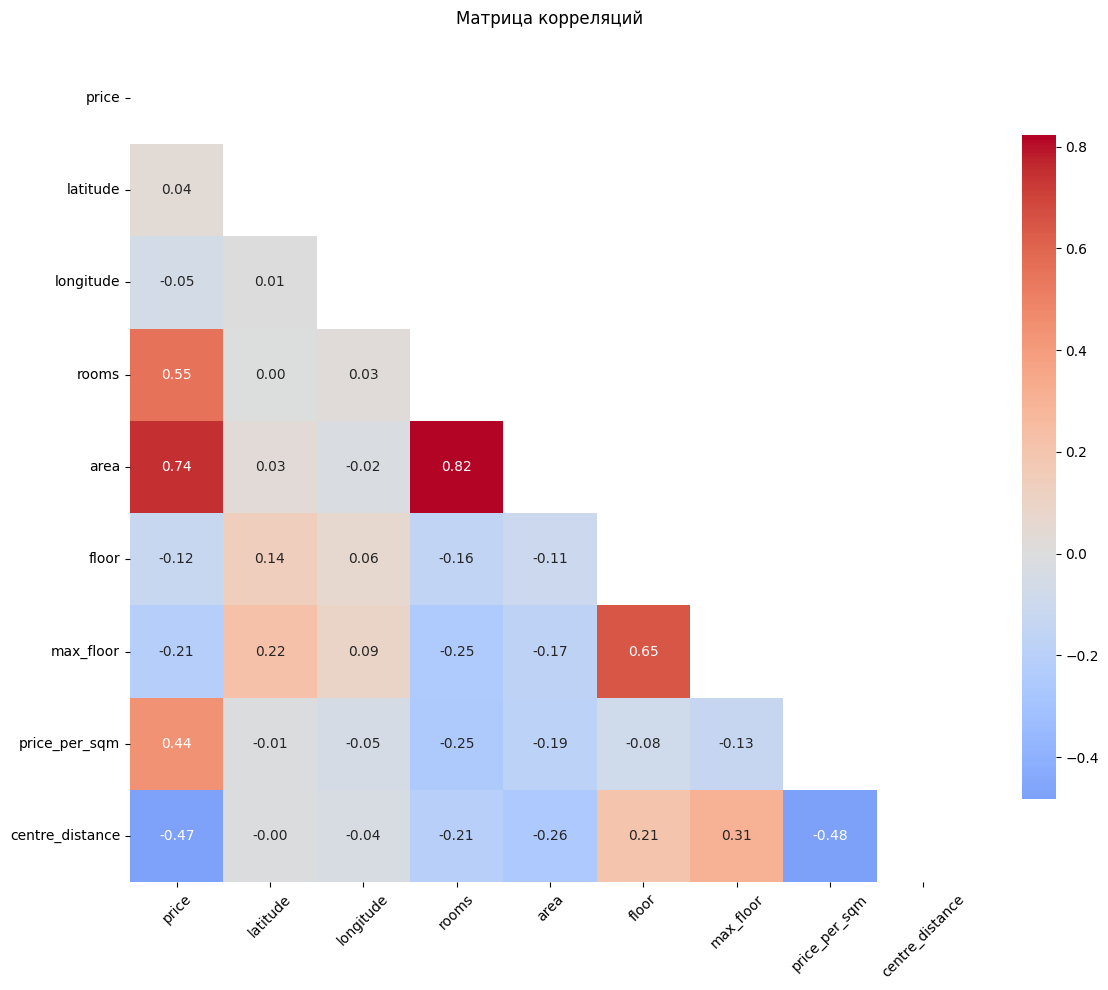

In [121]:
numeric_cols = offers_filtered.select_dtypes(include=[np.number]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in ['id']]

plt.figure(figsize=(12, 10))
corr = offers_filtered[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            annot_kws={"size": 10}, cbar_kws={"shrink": .8})
plt.title("Матрица корреляций", pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Цена:**

Сильно коррелирует с площадью (0.74) и количеством комнат (0.55). Это указывает на то, что более крупные и многокомнатные объекты, как правило, дороже. Умеренная корреляция с ценой за квадратный метр (0.44), что логично, так как цена напрямую зависит от стоимости квадратного метра.
Умеренная отрицательная корреляция с растоянием до центра (-0.47), которая значительно больше, чем с расстоянием до метро до этого.

**Расстояние до центра:**

Небольшая положительная корреляция с этажностью (0.21 и 0.31), так как в центре не строят высокие здания, из-за чего образовалась зависимость. Умеренная отрицательная корреляция с ценой за метр (-0.48).

На основе полученных данных попробуем сделать модель на основе трех признаков (площадь, количество комнат, расстояние до центра) возможностями библиотеки sklearn. Исследуем графики зависимостей цены от этих признаков.

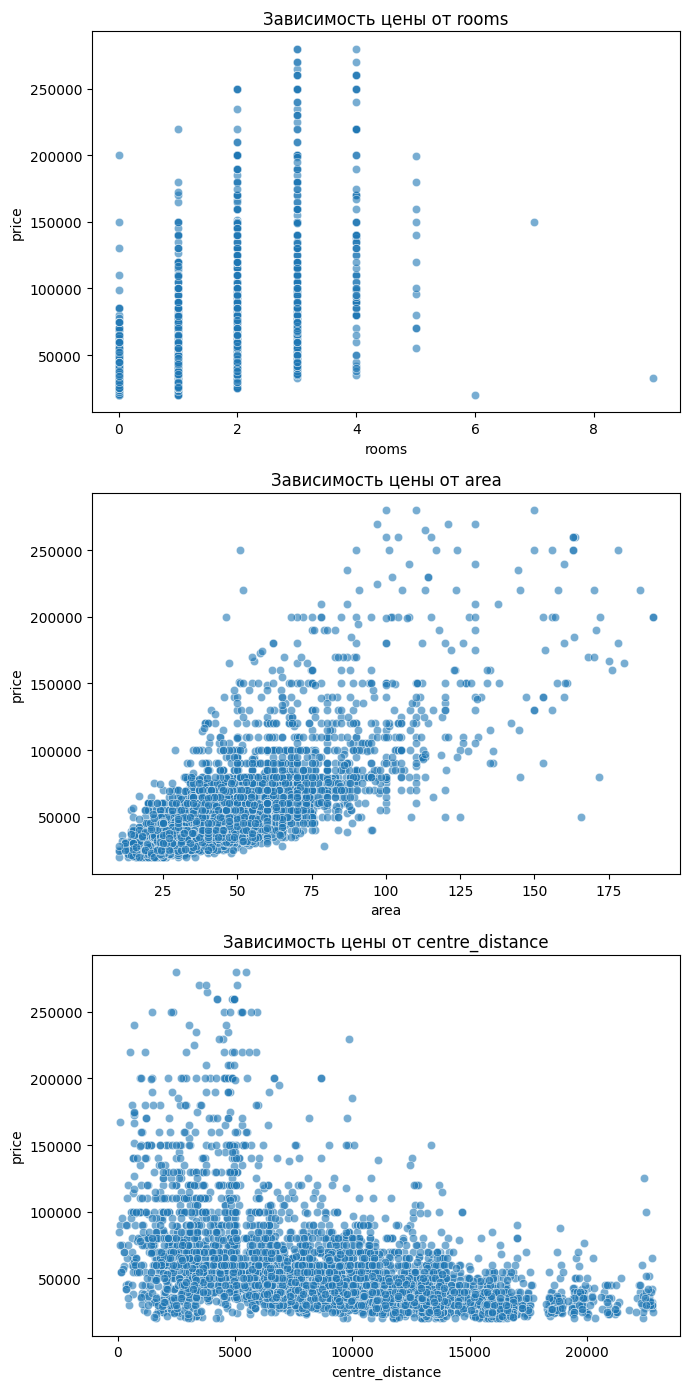

In [122]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 14))
features = ['rooms', 'area', 'centre_distance']
for i, col in enumerate(features):
    sns.scatterplot(x=offers_filtered[col], y=offers_filtered['price'], ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Зависимость цены от {col}')
plt.tight_layout()
plt.show()

# **Тестовая модель**

Создадим тестовую модели линейной и полиномиальной регрессии, чтобы посмотреть возможную точность модели. Используем возможности библиотеки sklearn.

Обозначим ряд признаков и целевую переменную. Разделим данные на выборки.

In [201]:
from sklearn.model_selection import train_test_split
X = offers_filtered[['area', 'centre_distance']]
y = offers_filtered['price']

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

Приведем переменные к единому масштабу.

In [232]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Создадим модель линейной регрессии и обучим ее. Выведем показатели коэффициента детерминации и среднеквадратической ошибки.

In [219]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Прогнозирование
y_pred_lin = lin_reg.predict(X_test_scaled)

# Оценка качества
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f'Линейная модель -> MSE: {mse_lin:.2f}, R2: {r2_lin:.4f}')
print('Коэффициенты модели:', dict(zip(X.columns, lin_reg.coef_)))

Линейная модель -> MSE: 372137916.49, R2: 0.6763
Коэффициенты модели: {'area': np.float64(21297.234935328), 'centre_distance': np.float64(-9857.370265215954)}


In [233]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Получаем имена новых признаков
poly_features = poly.get_feature_names_out(X.columns)
print("Примеры полиномиальных признаков:", poly_features[:10])

Примеры полиномиальных признаков: ['area' 'centre_distance' 'area^2' 'area centre_distance'
 'centre_distance^2']


In [235]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Прогнозирование
y_pred_poly = poly_reg.predict(X_test_poly)

# Оценка качества
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Полиномиальная модель -> MSE: {mse_poly:.2f}, R2: {r2_poly:.4f}')

Полиномиальная модель -> MSE: 345495803.89, R2: 0.6995


In [237]:
print("--- Сравнение моделей ---")
print(f"Линейная модель:      R2 = {r2_lin:.4f}, MSE = {mse_lin:.2f}")
print(f"{round(r2_lin * 100)}% предсказаний в пределах {round(mse_lin ** 0.5)} руб")
print(f"Полиномиальная модель: R2 = {r2_poly:.4f}, MSE = {mse_poly:.2f}")
print(f"{round(r2_poly * 100)}% предсказаний в пределах {round(mse_poly ** 0.5)} руб")

--- Сравнение моделей ---
Линейная модель:      R2 = 0.6763, MSE = 372137916.49
68% предсказаний в пределах 19291 руб
Полиномиальная модель: R2 = 0.6995, MSE = 345495803.89
70% предсказаний в пределах 18588 руб


In [240]:
print("Коэффициенты первой модели (2 признака):")

for i, j in dict(zip(['area', 'centre_distance'],
               lin_reg.coef_)).items():
    print(i, j)
print(f"Intercept: {lin_reg.intercept_:.2f}")

Коэффициенты первой модели (2 признака):
area 21297.234935328
centre_distance -9857.370265215954
Intercept: 51843.16


In [245]:
distance = float(input("Расстояние до центра (м): "))
area = float(input("Площадь (м²): "))

# Предсказание
price = lin_reg.predict(scaler.transform([[area, distance]]))[0]
print(f"Цена аренды: {price:,.0f} ₽")

Расстояние до центра (м): 1000
Площадь (м²): 50
Цена аренды: 75,143 ₽


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **Промежуточные выводы**

Был проведен анализ данных и построены графики зависимостей цены аренды от признаков. Наибольшую зависимость цена имеет от жилой площади, количества комнат и расстояния до центра. Были построены две тестовые модели (линейная и полиномиальные регрессии) для определения приблизительной точности модели на двух признаках. Модели показали неплохие результаты и для линейной, и для полиномиальной регрессии, где R2 превышает 0.6 почти на всех наборах данных.

Планируется подробнее изучить данные, найти функции зависимостей и написать модель линейной или полиномиальной регрессии вручную.